# Projekt klasyfikacji dwuwartościowej

Cel projektu: Zbudowanie i porównanie modeli klasyfikacji maszynowej, które przewidzą, czy dany pasażer przeżył katastrofę statku Titanic (klasa 1), czy nie (klasa 0).

Dane dotyczą titanicka i pochodzą z https://www.kaggle.com/datasets/yasserh/titanic-dataset/data.

Wykorzystany zbiór danych Titanic zawiera informacje o 891 pasażerach (obserwacji). Celem modelu jest przewidzenie, czy dany pasażer przeżył katastrofę (wartość 1), czy nie (wartość 0). Algorytm uczy się tego w sposób nadzorowany na podstawie parametrów wejściowych, takich jak klasa biletu, płeć, wiek oraz opłata za przejazd. Aby model mógł poprawnie wyznaczyć granicę decyzyjną, zbiór ten wymaga wcześniejszej obróbki, polegającej między innymi na zmapowaniu tekstowej zmiennej płci na wartości liczbowe oraz uzupełnieniu brakujących informacji o wieku pasażerów za pomocą wartości średniej z tej kolumny.

# Wczytanie danych

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df1 = pd.read_csv("/content/drive/MyDrive/data/titanic.csv")
df1

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# 1. Opracowanie i czyszczenie danych wejściowych

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Zanim dane trafią do algorytmów, musimy je przetworzyć na czyste liczby:

Odrzucenie cech nieistotnych: Kolumny takie jak Imię, Numer biletu, nasza wygenerowana Data zakupu biletu oraz ID pasażera nie niosą uniwersalnych wzorców dla algorytmów uczenia maszynowego.

Obsługa braków danych:
*   Kolumna Age (wiek) ma ok. 20% braków – zastępujemy je wartością medianą.
*   Kolumna Cabin (kabina) ma ponad 70% braków – całkowicie ją usuwamy.
*   Kolumna Embarked (port) ma tylko 2 braki – po prostu usuwamy te dwa puste wiersze.



Mapowanie zmiennych opisowych: Zamieniamy wartości tekstowe płci i portu zaokrętowania na wartości liczbowe (np. mężczyzna = 0, kobieta = 1).

## 1.1. Naprawa braków danych

Podsumowania braków danych:

In [ ]:
mask = df1.isnull()
total = mask.sum()
per = 100*mask.mean()
missing_data = pd.concat([total, per], axis=1,keys=['wartosc brakujaca', 'procent'])
missing_data.sort_values(by='procent', ascending=False, inplace=True)
missing_data

,wartosc brakujaca,procent
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Name,0,0.000000
Pclass,0,0.000000
Survived,0,0.000000
Sex,0,0.000000
Parch,0,0.000000
SibSp,0,0.000000


Zmienna "Cabin" posiada dużo braków danych i nie jest istotna w mojej analizie, dlatego postanowiłam usunąć tą kolumnę.

In [ ]:
df = df1.drop('Cabin', axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


Braki danych dla zmiennej "Embarked" usuwam, ponieważ nie ma to dużego wpływu na dalszą analizę (braków jest niewiele - 2 wiersze).



In [ ]:
df = df.dropna(subset=['Embarked'])

Dla zmiennej "Age" braki wartości zastępuję medianą.

In [ ]:
# 1. Sprawdzamy, jak wygląda mediana wieku w poszczególnych podgrupach
print("Mediana wieku w podziale na Klasę i Płeć:")
print(df.groupby(['Pclass', 'Sex'])['Age'].median())
print("-" * 40)

# 2. Imputacja grupowa: wypełniamy braki w wieku dopasowaną medianą z danej grupy
df['Age'] = df['Age'].fillna(df.groupby(['Pclass', 'Sex'])['Age'].transform('median'))

# 3. Zaokrąglamy wiek do pełnych lat i konwertujemy na liczby całkowite
df['Age'] = df['Age'].round().astype(int)


Mediana wieku w podziale na Klasę i Płeć:
Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64
----------------------------------------


Sprawdzanie zbalansowania zmiennej "Survived"

Liczba osób w poszczególnych klasach (0 - nie przeżył, 1 - przeżył):
Survived
0    549
1    340
Name: count, dtype: int64


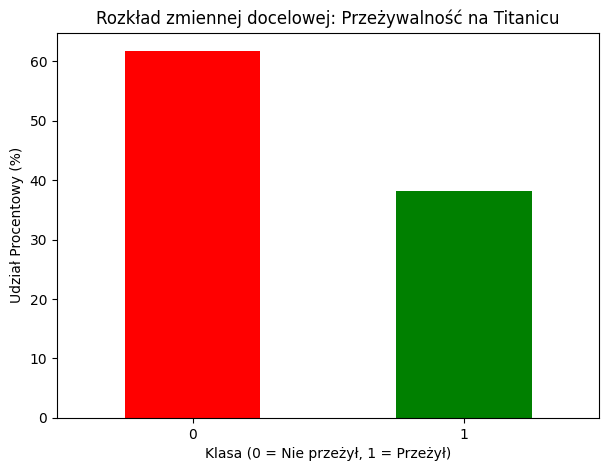

In [ ]:
liczba_osob = df['Survived'].value_counts()
procent_osob = df['Survived'].value_counts(normalize=True) * 100
print("Liczba osób w poszczególnych klasach (0 - nie przeżył, 1 - przeżył):")
print(liczba_osob)

# Wykres
plt.figure(figsize=(7, 5))
kolory = ['red', 'green']
ax = procent_osob.plot(kind='bar', color=kolory)
plt.title('Rozkład zmiennej docelowej: Przeżywalność na Titanicu')
plt.xlabel('Klasa (0 = Nie przeżył, 1 = Przeżył)')
plt.ylabel('Udział Procentowy (%)')
plt.xticks(rotation=0)
plt.show()

In [ ]:
df.info() # sprawdzenie czy już wszystkie braki zostały naprawione

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    int64  
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(1), int64(6), object(4)
memory usage: 83.3+ KB


## 1.2. Przekształcanie danych.

Mapowanie 'Embarked' na liczby

In [ ]:
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

Zmiana wartości w zmiennej "Sex" na wartości liczbowe (facet - 0, kobieta - 1).

In [ ]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [ ]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22,1,0,A/5 21171,7.2500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38,1,0,PC 17599,71.2833,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26,0,0,STON/O2. 3101282,7.9250,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35,1,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",0,35,0,0,373450,8.0500,0
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27,0,0,211536,13.0000,0
887,888,1,1,"Graham, Miss. Margaret Edith",1,19,0,0,112053,30.0000,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,22,1,2,W./C. 6607,23.4500,0
889,890,1,1,"Behr, Mr. Karl Howell",0,26,0,0,111369,30.0000,1


In [ ]:
# Usuwam kolumny z danymi opisowymi - nieistotne dla naszej analizy
X = df.drop(['Survived', 'Name', 'Ticket', 'PassengerId',], axis=1)
y = df['Survived']

In [ ]:
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22,1,0,7.2500,0
1,1,1,38,1,0,71.2833,1
2,3,1,26,0,0,7.9250,0
3,1,1,35,1,0,53.1000,0
4,3,0,35,0,0,8.0500,0
...,...,...,...,...,...,...,...
886,2,0,27,0,0,13.0000,0
887,1,1,19,0,0,30.0000,0
888,3,1,22,1,2,23.4500,0
889,1,0,26,0,0,30.0000,1


# 2. Podstawowa analiza statystyczna przed skalowaniem

Zanim przejdę do uczenia maszynowego, chcę sprawdzić, jak te dane się rozkładają. Najpierw wyciągam podstawowe statystyki (średnie, min, max), a potem rysuję sobie kilka wykresów, żeby zobaczyć to wizualn

## 2.1. Dodatkowa wizualizacja: Wiek, Płeć, Klasa Pasażera i Status Przeżycia (Swarmplot)

Swarmplot pozwala zobaczyć rozkład wieku pasażerów w podziale na płeć i klasę biletu — każda kropka to jedna osoba. Kolor kropki wskazuje, czy pasażer przeżył (1) - zielony czy zginął (0) - pomarańczowy. Dzięki temu w jednym wykresie mogę intuicyjnie ocenić, jak klasa biletu, płeć i wiek łącznie wpływały na szanse przeżycia.

W odróżnieniu od PCA (punkt 5.1), swarmplot nie przetwarza ani nie redukuje danych — pokazuje je w ich oryginalnej formie. To narzędzie do wstępnej, intuicyjnej analizy zależności między konkretnymi zmiennymi.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 21.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 25.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 26.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


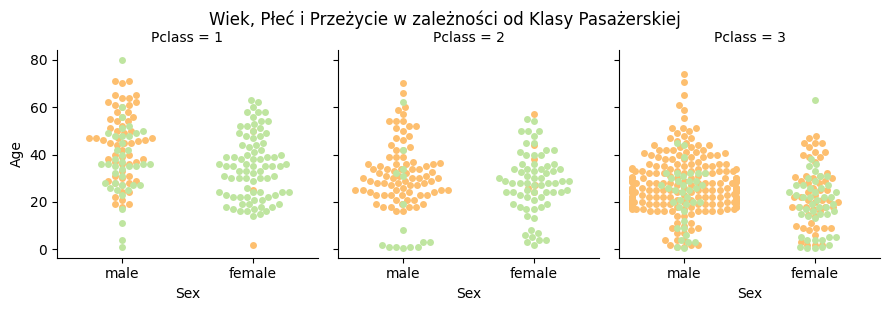

In [ ]:
g = sns.FacetGrid(df1.dropna(subset=['Age']), col='Pclass', hue='Survived', palette="Spectral")
g.map(sns.swarmplot, 'Sex', 'Age', order=["male", "female"], hue_order=[0, 1])
plt.suptitle('Wiek, Płeć i Przeżycie w zależności od Klasy Pasażerskiej', y=1.02)
plt.show()

### Wnioski:
- Zasada "kobiety i dzieci pierwsze": Wykres udowadnia, że płeć była kluczowym predyktorem przeżycia. W każdej z trzech klas kobiety miały  wyższe szanse na ratunek (gęste skupiska zielonych kropek) niż mężczyźni (absolutna dominacja pomarańczowych kropek). Dodatkowo, na dole osi wieku u mężczyzn (zwłaszcza w 2. i 3. klasie) widać pojedyncze zielone kropki – to uratowani mali chłopcy, co potwierdza historyczny priorytet ewakuacji dzieci.

- Status społeczny (Klasa pasażerska): Klasa biletu silnie koreluje z przeżywalnością. Kobiety z klasy pierwszej i drugiej ocalały niemal w komplecie. Największy dramat rozegrał się w trzeciej klasie – widać tam potężne, gęste skupisko ofiar (pomarańczowy kolor) wśród dorosłych mężczyzn, a także znacząco wyższy odsetek zmarłych kobiet w porównaniu do klas wyższych.

## 2.2. Podstawowe statystyki

In [ ]:
display(X.describe().round(2))

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,889.00,889.00,889.00,889.00,889.00,889.00,889.00
mean,2.31,0.35,29.08,0.52,0.38,32.10,0.36
std,0.83,0.48,13.26,1.10,0.81,49.70,0.64
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2.00,0.00,22.00,0.00,0.00,7.90,0.00
50%,3.00,0.00,26.00,0.00,0.00,14.45,0.00
75%,3.00,1.00,36.00,1.00,0.00,31.00,1.00
max,3.00,1.00,80.00,8.00,6.00,512.33,2.00


/tmp/ipykernel_10962/1928974056.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, ax=axes[0], palette='Set1')
/tmp/ipykernel_10962/1928974056.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X['Sex'], y=y, ax=axes[2], palette='Set2')


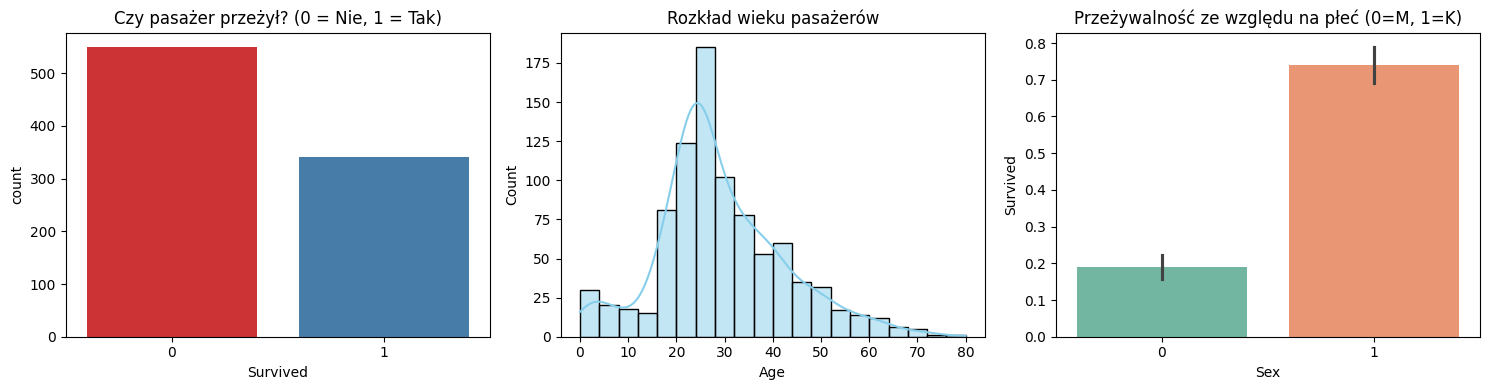

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(x=y, ax=axes[0], palette='Set1')
axes[0].set_title('Czy pasażer przeżył? (0 = Nie, 1 = Tak)')

sns.histplot(X['Age'], bins=20, kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Rozkład wieku pasażerów')

sns.barplot(x=X['Sex'], y=y, ax=axes[2], palette='Set2')
axes[2].set_title('Przeżywalność ze względu na płeć (0=M, 1=K)')

plt.tight_layout()
plt.show()

Wniosek:
Po pierwsze widzę, że grupy są niezbalansowane – dużo więcej osób zginęło (ponad 500) niż przeżyło (około 340). Na wykresie wieku mam duży skok w okolicach 30 lat – to efekt mojego uzupełniania braków medianą. Z trzeciego wykresu jasno wynika to, że kobiety (1) miały znacznie większe szanse na przeżycie niż mężczyźni(0).

# 3. Skalowanie danych do przedziału [0,1]

Przrzeskaluje teraz dane do przedziału [0, 1]. Jest to  ważne, bo modele takie jak KNN czy SVM liczą odległości między punktami. Gdybym tego nie zrobiła, to zmienna "Wiek" (gdzie mamy wartości rzędu 40-50) zdominowałaby zmienną "Klasa" (wartości od 1 do 3), a algorytm pomyślałby, że wiek jest ważniejszy tylko dlatego, że ma wyższe liczby. Używam więc MinMaxScaler.

## 3.1. Skalowanie

In [ ]:
from sklearn.preprocessing import MinMaxScaler
# Skaluję wszystkie cechy do przedziału od 0 do 1
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled_array = scaler.fit_transform(X)

# DataFrame, żeby było czytelniej
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

print("Przykładowe dane po zastosowaniu MinMaxScalera:")
display(X_scaled.head(3))

Przykładowe dane po zastosowaniu MinMaxScalera:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1.0,0.0,0.275,0.125,0.0,0.014151,0.0
1,0.0,1.0,0.475,0.125,0.0,0.139136,0.5
2,1.0,1.0,0.325,0.000,0.0,0.015469,0.0


## 3.2 Podziału danych na zbiór treningowy i testowy

In [ ]:
# Podział na zbiór treningowy (80%) i testowy (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Rozmiar zbioru treningowego: {X_train.shape}")
print(f"Rozmiar zbioru testowego: {X_test.shape}")

Rozmiar zbioru treningowego: (711, 7)
Rozmiar zbioru testowego: (178, 7)


## 3.3 Balansowanie klas za pomocą metody SMOTE

W naszym zbiorze danych z Titanica występuje problem tzw. niezbalansowania klas – ofiar (klasa 0) jest znacznie więcej niż ocalałych (klasa 1).

Do rozwiązania tego problemu użyto algorytmu SMOTE
Zamiast po prostu naiwnie kopiować istniejące wiersze z ocalałymi (co mogłoby doprowadzić do overfittingu), SMOTE analizuje cechy ocalałych pasażerów i generuje zupełnie nowe, sztuczne (ale matematycznie i logicznie prawdopodobne) wektory danych, aż obie grupy wyrównają się do proporcji 50/50.

/tmp/ipykernel_10962/2435690438.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Ofiary (0)', 'Ocaleni (1)'], y=[ile_0_przed, ile_1_przed], ax=axes[0], palette=['#e74c3c', '#2ecc71'])
/tmp/ipykernel_10962/2435690438.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Ofiary (0)', 'Ocaleni (1)'], y=[ile_0_po, ile_1_po], ax=axes[1], palette=['#e74c3c', '#2ecc71'])


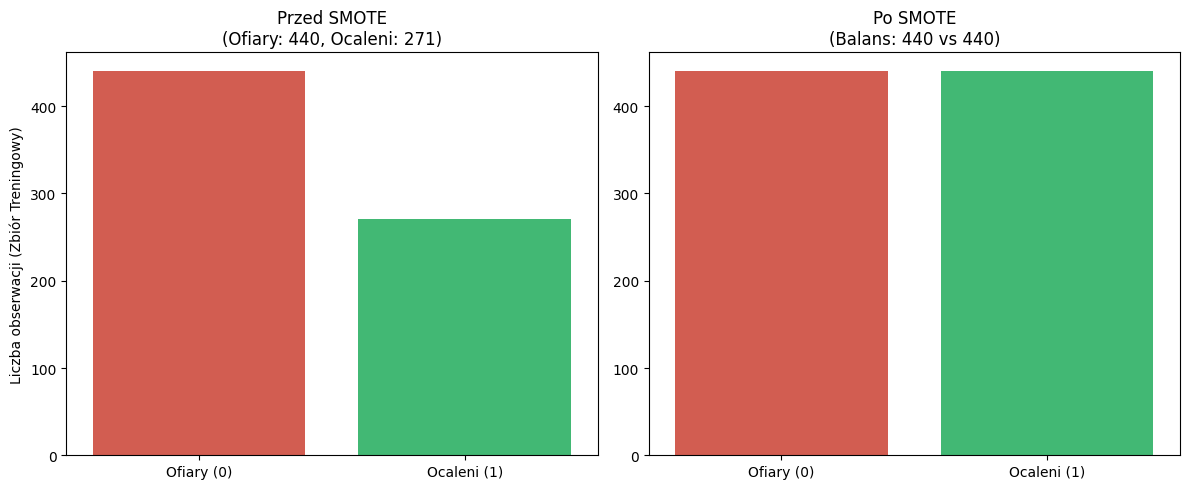

In [ ]:
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Zliczenie klas przed SMOTE
ile_0_przed = sum(y_train == 0)
ile_1_przed = sum(y_train == 1)

# Zastosowanie SMOTE (tylko na zbiorze treningowym!)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Zliczenie klas po SMOTE
ile_0_po = sum(y_train_smote == 0)
ile_1_po = sum(y_train_smote == 1)

# wykresy (Przed i Po)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=['Ofiary (0)', 'Ocaleni (1)'], y=[ile_0_przed, ile_1_przed], ax=axes[0], palette=['#e74c3c', '#2ecc71'])
axes[0].set_title(f'Przed SMOTE\n(Ofiary: {ile_0_przed}, Ocaleni: {ile_1_przed})')
axes[0].set_ylabel('Liczba obserwacji (Zbiór Treningowy)')

sns.barplot(x=['Ofiary (0)', 'Ocaleni (1)'], y=[ile_0_po, ile_1_po], ax=axes[1], palette=['#e74c3c', '#2ecc71'])
axes[1].set_title(f'Po SMOTE\n(Balans: {ile_0_po} vs {ile_1_po})')

plt.tight_layout()
plt.show()


X_train = X_train_smote
y_train = y_train_smote

# 4. Korelacja

Teraz generuję macierz korelacji (cieplną mapę), żeby sprawdzić, które zmienne są ze sobą powiązane i co najsilniej wpływa na to, czy pasażer przeżył (Survived).

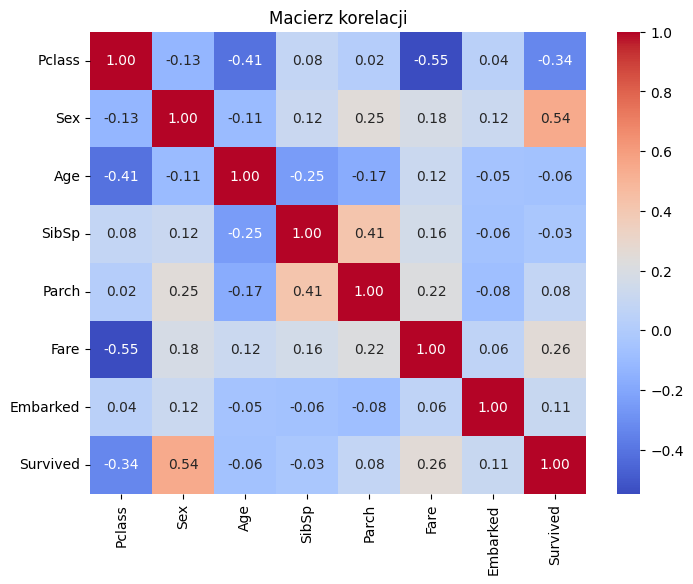

In [ ]:
df_corr = X_scaled.copy()
df_corr['Survived'] = y.values

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Macierz korelacji")
plt.show()

Wnioski:
Mapa potwierdza to, co widziałam wcześniej na wykresie: Sex (płeć) najsilniej dodatnio koreluje z przeżyciem (współczynnik 0.54). Ciekawa jest też korelacja ze zmienną Pclass (klasa biletu). Jest ona ujemna (-0.34), co logicznie oznacza, że im niższy numerek klasy (czyli jedynka – pierwsza klasa), tym szanse na przeżycie rosły.




# 5. PCA i t-SNE (Redukcja wymiarów)

## 5.1. PCA

Mam sporo cech opisujących pasażerów (wiek, płeć, klasa, itd.). Chcę sprawdzić, czy da się to wszystko spłaszczyć do zaledwie dwóch głównych wymiarów (składowych), nie tracąc przy tym najważniejszych informacji. Analiza Głównych Składowych (PCA) pozwala mi zredukować wymiarowość i narysować dane na płaskim wykresie 2D.

Czerwone kropki to ofiary (0), a niebieskie to ocaleni (1). Chcę zobaczyć, czy te dwie grupy na wykresie ułożą się w jakieś wyraźne klastry, które łatwo od siebie oddzielić.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

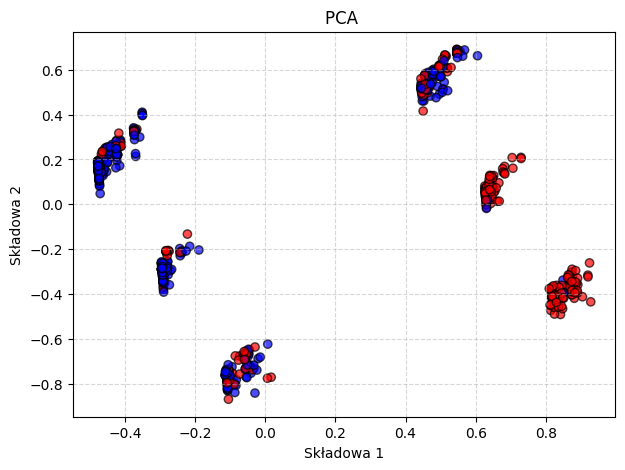

In [ ]:
# Inicjalizacja i dopasowanie algorytmu PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Wykres dla PCA
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='bwr', alpha=0.7, edgecolor='k')
plt.title('PCA ')
plt.xlabel('Składowa 1')
plt.ylabel('Składowa 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Na wykresie widać, że punkty formują pewne grupy, ale kropki czerwone i niebieskie dość mocno się przenikają. PCA wykonało matematyczną kompresję, ale widać wyraźnie, że nie wystarczy narysować jednej prostej linii, aby idealnie oddzielić tych, co przeżyli, od tych, co zginęli.

## 5.2. t-SNE

Ponieważ PCA to metoda liniowa, sprawdzamvalgorytm– t-SNE. Jest to metoda nieliniowa, która dużo lepiej radzi sobie z zachowywaniem lokalnych podobieństw między punktami. Liczę na to, że t-SNE pokaże mi bardziej naturalne grupki (klastry) pasażerów o podobnych cechach.

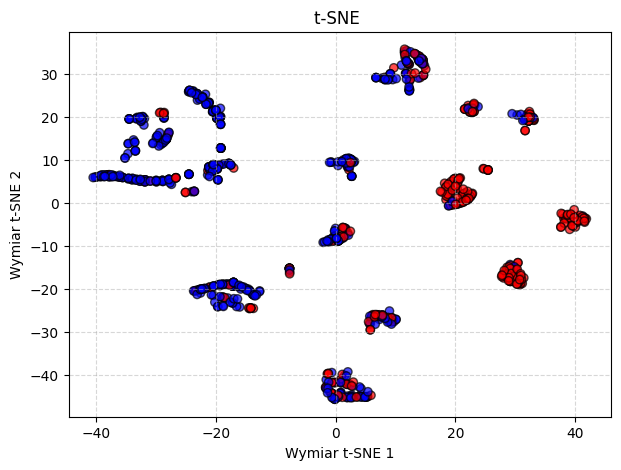

In [ ]:
# Inicjalizacja i dopasowanie algorytmu t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Wykres dla t-SNE
plt.figure(figsize=(7, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='bwr', alpha=0.7, edgecolor='k')
plt.title('t-SNE ')
plt.xlabel('Wymiar t-SNE 1')
plt.ylabel('Wymiar t-SNE 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

wnioski:
Wykres t-SNE wygląda inaczej niż PCA. Punkty zbiły się w bardzo wyraźne "wyspy" (klastry), co oznacza, że algorytm znalazł grupy pasażerów o bardzo podobnych profilach (np. kobiety z pierwszej klasy w jednym miejscu, a mężczyźni z trzeciej w innym). Mimo to, w niektórych klastrach nadal mieszają się kolory niebieski i czerwony. To tylko utwierdza mnie w przekonaniu, że problem Titanica jest złożony i aby dobrze przewidzieć przeżycie, muszę użyć zaawansowanych modeli uczenia maszynowego.

# 6. Budowa i ocena modeli (Regresja, KNN, SVM)

Regresję Logistyczną, K-Najbliższych Sąsiadów (KNN) oraz Maszynę Wektorów Nośnych (SVM).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Inicjalizacja i trening modelu Regresji Logistycznej
model_lr = LogisticRegression(random_state=42)
model_lr.fit(X_train, y_train)

LogisticRegression(random_state=42)

## 6.1. Regresja Logistyczna - Macierz błedów i istotność cech

Ten model oblicza prawdopodobieństwo (od 0 do 1), czy dany pasażer przeżył katastrofę. Algorytm analizuje każdą cechę (np. wiek, płeć, klasę) i nadaje im odpowiednie wagi.

### 6.1.1 Ranking istotności cech


Ranking istotności cech według Regresji Logistycznej:


,Cecha,Waga (istotność)
0,Age,2.605506
1,Sex,2.390443
2,SibSp,2.158345
3,Pclass,1.993566
4,Fare,0.741769
5,Embarked,0.511777
6,Parch,0.414658


/tmp/ipykernel_10962/1607314851.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Waga (istotność)', y='Cecha', data=importance, palette='viridis')


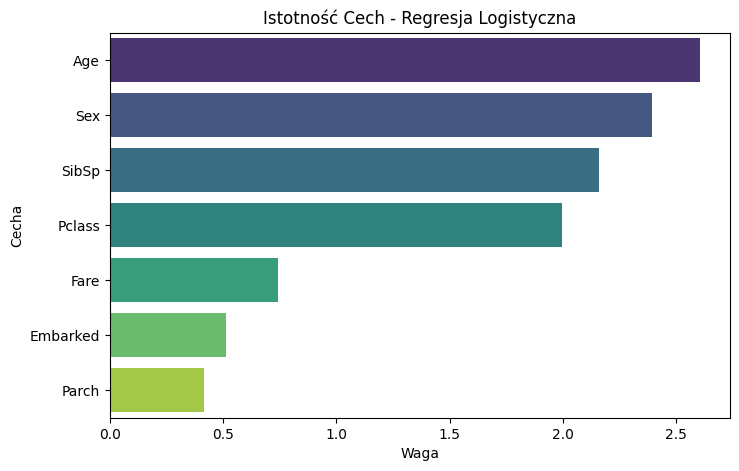

In [ ]:
# Ranking istotności cech
importance = pd.DataFrame({
    'Cecha': X_train.columns,
    'Waga (istotność)': np.abs(model_lr.coef_[0])
}).sort_values(by='Waga (istotność)', ascending=False).reset_index(drop=True)

print("\nRanking istotności cech według Regresji Logistycznej:")
display(importance)

# Wykres istotności cech
plt.figure(figsize=(8, 5))
sns.barplot(x='Waga (istotność)', y='Cecha', data=importance, palette='viridis')
plt.title('Istotność Cech - Regresja Logistyczna')
plt.xlabel('Waga')
plt.ylabel('Cecha')
plt.show()


### 6.1.2 Dokładność

In [ ]:
# Predykcja na zbiorze testowym
y_pred_lr = model_lr.predict(X_test)
print(f"Dokładność (Accuracy) Regresji Logistycznej: {accuracy_score(y_test, y_pred_lr):.2f}")


Dokładność (Accuracy) Regresji Logistycznej: 0.78


### 6.1.3 Macierz błedów

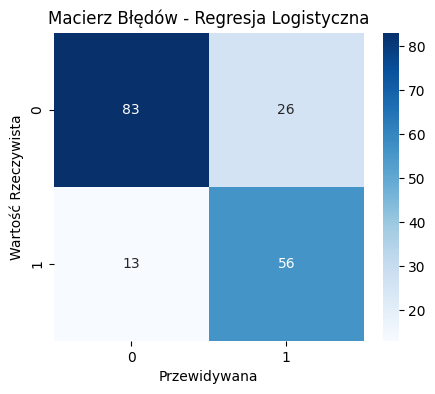

In [ ]:
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, cmap='Blues')
plt.title('Macierz Błędów - Regresja Logistyczna')
plt.ylabel('Wartość Rzeczywista')
plt.xlabel('Przewidywana')
plt.show()

Wnioski:

Model osiągnął dokładność na poziomie 78%.

Ranking istotności potwierdza to, co sugerowały wcześniejsze wykresy i macierz korelacji: płeć (Sex) ma zdecydowanie największą wagę, a zaraz po niej znajduje się klasa biletu (Pclass).

Macierz błędów pokazuje, że model rzadko myli się w przypadku ofiar (zaledwie w kilkunastu przypadkach przypisał im przetrwanie).

### 6.1.1. Raport klasyfikacji dla Regresji logistycznej

In [ ]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.86      0.76      0.81       109
           1       0.68      0.81      0.74        69

    accuracy                           0.78       178
   macro avg       0.77      0.79      0.78       178
weighted avg       0.79      0.78      0.78       178



Wnioski:

*  **Ogólna dokładność (Accuracy)**: Model osiągnął 78% poprawnych predykcji, co jest solidnym wynikiem dla tego problemu.

*  **Klasa 0 (Nie przeżyli)**:
    *   **Precyzja (Precision)** wynosząca 0.86 oznacza, że 86% pasażerów, których model przewidział jako nieprzeżywających, faktycznie zginęło.
    *   **Czułość (Recall)** na poziomie 0.76 wskazuje, że model poprawnie zidentyfikował 76% wszystkich pasażerów, którzy faktycznie nie przeżyli.
    *   **F1-Score** dla tej klasy to 0.81, co świadczy o dobrej równowadze między precyzją a czułością dla klasy większościowej.

*  **Klasa 1 (Przeżyli)**:
    *   **Precyzja (Precision)** 0.68 oznacza, że 68% pasażerów, których model przewidział jako przeżywających, faktycznie przeżyło. To jest wynik niższy niż dla klasy 0, ale akceptowalny.
    *   **Czułość (Recall)** na poziomie 0.81 jest bardzo ważnym wskaźnikiem dla tej klasy, ponieważ pokazuje, że model zdołał poprawnie zidentyfikować 81% wszystkich osób, które faktycznie przeżyły katastrofę. Wysoka czułość dla klasy pozytywnej (przeżyli) jest często priorytetem w tego typu problemach.
    *   **F1-Score** dla tej klasy to 0.74. Jest to solidny wynik, szczególnie biorąc pod uwagę, że jest to klasa mniejszościowa, i świadczy o dobrym kompromisie między precyzją a czułością w identyfikowaniu ocalałych.

## 6.2. K-Najbliższych Sąsiadów (KNN)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

Zanim ustalę parametr `n_neighbors/najlepsze_k` (czyli liczbę sąsiadów - k), chcę sprawdzić, dla jakiej wartości mój model poradzi sobie najlepiej. W tym celu przetestuje wartości k od 1 do 20 i narysuje wykres dokładności (metoda łokcia dla błędu). Dopiero na podstawie tego wykresu wybiorę ostateczne $k$.

### 6.2.1. Metoda łokcia - szukanie optymalnego "k"

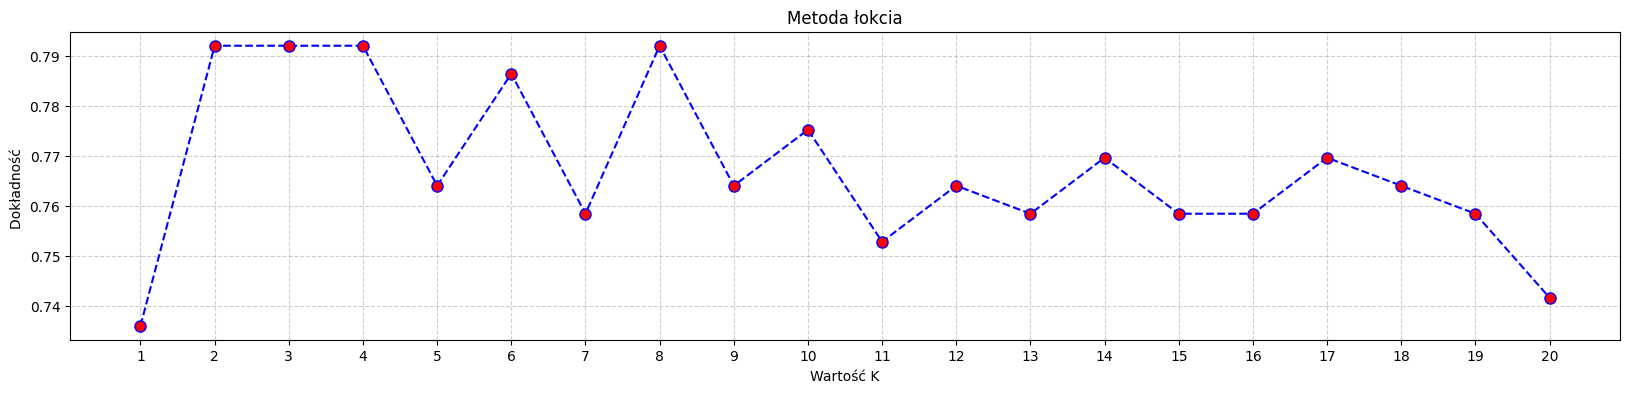


Z wykresu metody łokcia wynika, że optymalna wartość to k = 2.


In [ ]:
dokladnosci = []
k_wartosci = range(1, 21)

# Pętla testująca k od 1 do 20
for k in k_wartosci:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    y_pred_temp = knn_temp.predict(X_test)
    dokladnosci.append(accuracy_score(y_test, y_pred_temp))

# wykres
plt.figure(figsize=(20 ,4))
plt.plot(k_wartosci, dokladnosci, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)
plt.title('Metoda łokcia')
plt.xlabel('Wartość K')
plt.ylabel('Dokładność ')
plt.xticks(k_wartosci)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Wybór k
najlepsze_k = dokladnosci.index(max(dokladnosci)) + 1
print(f"\nZ wykresu metody łokcia wynika, że optymalna wartość to k = {najlepsze_k}.")

### 6.2.2. KNN

Ten algorytm opiera się na szukaniu podobieństw. Kiedy ocenia nowego pasażera, wylicza jego matematyczną odległość do innych osób z danych treningowych i patrzy na losy wyznaczonej liczby najbliższych "sąsiadów".

Dokładność (Accuracy) modelu KNN: 0.79


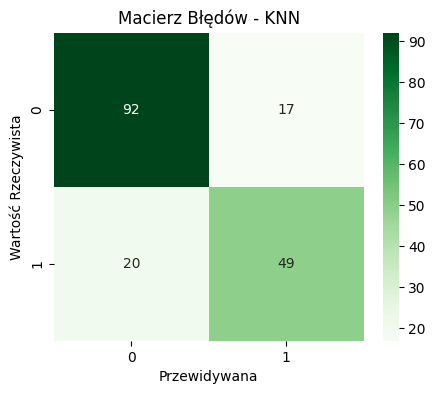

In [ ]:
# Inicjalizacja i trening modelu KNN
model_knn = KNeighborsClassifier(n_neighbors=najlepsze_k)
model_knn.fit(X_train, y_train)

# Predykcja na zbiorze testowym
y_pred_knn = model_knn.predict(X_test)
print(f"Dokładność (Accuracy) modelu KNN: {accuracy_score(y_test, y_pred_knn):.2f}")

#  macierzy błędów dla KNN
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, cmap='Greens')
plt.title('Macierz Błędów - KNN')
plt.ylabel('Wartość Rzeczywista')
plt.xlabel('Przewidywana')
plt.show()

Wynik dokładności modelu KNN (0.79) jest bardzo podobny do Regresji Logistycznej (0.78). Patrząc na macierz błędów i raport klasyfikacji, KNN bardzo dobrze identyfikuje osoby, które nie przeżyły (klasa 0), z wysoką precyzją (0.82) i czułością (0.84). Jednakże, w przypadku osób, które przeżyły (klasa 1), jego czułość (0.71) jest nieco niższa w porównaniu do Regresji Logistycznej, co oznacza, że model ten nieco częściej 'przegapia' prawdziwych ocalałych. Mimo to, ogólna skuteczność modelu po przeskalowaniu danych jest wysoka.

### 6.2.3. Raport klasyfikacji

In [ ]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       109
           1       0.74      0.71      0.73        69

    accuracy                           0.79       178
   macro avg       0.78      0.78      0.78       178
weighted avg       0.79      0.79      0.79       178



Wnioski:

*   **Ogólna dokładność (Accuracy)**: Model KNN osiągnął dokładność na poziomie 0.79, co jest porównywalne z Regresją Logistyczną.

*   **Klasa 0 (Nie przeżyli)**: Model ma wysoką precyzję (0.82) i czułość (0.84) dla tej klasy, co oznacza, że bardzo dobrze identyfikuje osoby, które nie przeżyły. F1-Score dla tej klasy to 0.83.

*   **Klasa 1 (Przeżyli)**: Precyzja wynosi 0.74, a czułość 0.71. Oznacza to, że model jest dość precyzyjny w identyfikowaniu ocalałych, ale nieco gorzej radzi sobie z wyłapywaniem wszystkich faktycznie ocalałych osób. F1-Score dla tej klasy (0.73) jest solidny, ale niższy niż dla klasy 0.

## 6.3. Support Vector Machine (SVM)

Support Vector Machine (SVM) to algorytm, który szuka optymalnej 'granicy' (hiperpłaszczyzny) w przestrzeni danych, która najlepiej rozdziela klasy. W tym przypadku SVM będzie starał się znaleźć linię, która jak najskuteczniej oddzieli pasażerów, którzy przeżyli, od tych, którzy zginęli. Może to być linia prosta (liniowy SVM) lub bardziej złożona krzywa, jeśli dane są nieliniowo rozdzielne.

### 6.3.1. Automatyczne szukanie: rodzaj matematycznego cięcia (kernel) oraz siła regularyzacji (C)

In [ ]:
from sklearn.model_selection import GridSearchCV

Zanim ustalę parametry dla modelu SVM, chcę sprawdzić, przy jakich ustawieniach poradzi on sobie najlepiej. W tym modelu kluczowe są dwa parametry: rodzaj matematycznego cięcia (kernel) oraz siła regularyzacji (C).

Zamiast zgadywać, wykorzystam metodę przeszukiwania siatki (GridSearchCV).

Algorytm sam przetestuje różne kombinacje tych parametrów i sprawdzi ich dokładność. Dopiero na podstawie tego wybiorę ostateczne parametry do mojego modelu.

Model SVM oferuje również jądro wielomianowe i sigmoidalne. Zdecydowałam się jednak na przetestowanie tylko 'linear' i 'rbf', ponieważ 'rbf' jest uznawane za najbardziej uniwersalne i domyślne jądro w klasyfikacji, a 'linear' świetnie sprawdza się jako punkt odniesienia dla prostych granic. Odrzuciłam jądro wielomianowe ('poly'), ponieważ testowanie stopnia wielomianu bardzo wydłużyało czas obliczeń całego GridSearchCV, najprawdopodobniej nie poprawiając wyniku.

In [ ]:

# Definiuję siatkę parametrów do przetestowania
param_grid_svm = {
    'C': [10, 20, 40, 60, 100],
    'kernel': ['linear', 'rbf']
}

grid_cv_svm = GridSearchCV(SVC(random_state=42),
                           param_grid=param_grid_svm,
                           cv=3,
                           scoring='accuracy',
                           n_jobs=-1)

# Trening
grid_cv_svm.fit(X_train, y_train)

#najlepsze parametry
najlepsze_parametry_svm = grid_cv_svm.best_params_
print(f"Najlepsze parametry znalezione przez GridSearchCV to: {najlepsze_parametry_svm}")

Najlepsze parametry znalezione przez GridSearchCV to: {'C': 60, 'kernel': 'rbf'}


### 6.3.2. SVM


Ostateczna dokładność (Accuracy) zoptymalizowanego modelu SVM: 0.80


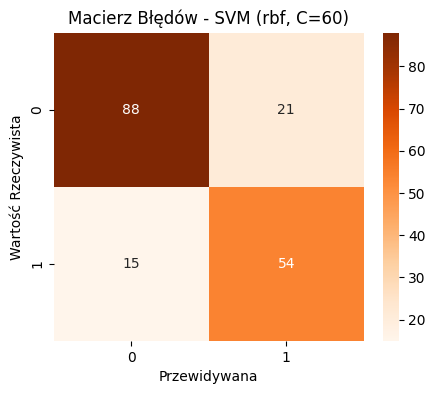

In [ ]:
# Predykcja najlepszym znalezionym modelem
model_svm = grid_cv_svm.best_estimator_
y_pred_svm = model_svm.predict(X_test)
print(f"\nOstateczna dokładność (Accuracy) zoptymalizowanego modelu SVM: {accuracy_score(y_test, y_pred_svm):.2f}")

#macierzy błędw
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Oranges')

plt.title(f"Macierz Błędów - SVM ({najlepsze_parametry_svm['kernel']}, C={najlepsze_parametry_svm['C']})")
plt.ylabel('Wartość Rzeczywista')
plt.xlabel('Przewidywana')
plt.show()

Wnioski:
Model SVM, zwłaszcza po optymalizacji hiperparametrów, osiągnął bardzo dobrą dokładność (0.80), co jest najlepszym wynikiem spośród dotychczas testowanych modeli. Macierz błędów pokazuje, że model radzi sobie efektywnie zarówno z przewidywaniem ofiar, jak i ocalałych, choć nadal wykazuje pewne pomyłki. Fakt, że najlepszym jądrem okazało się 'rbf' (radialna funkcja bazowa), sugeruje, że zależności w danych nie są w pełni liniowe i model SVM skutecznie znajduje bardziej złożone granice decyzyjne.

### 6.3.3. Raport klasyfikacji

In [ ]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.85      0.81      0.83       109
           1       0.72      0.78      0.75        69

    accuracy                           0.80       178
   macro avg       0.79      0.79      0.79       178
weighted avg       0.80      0.80      0.80       178



Wnioski:

*   **Ogólna dokładność (Accuracy)**: Zoptymalizowany model SVM osiągnął dokładność 80%, co jest najlepszym wynikiem spośród wszystkich trzech analizowanych modeli (Regresja Logistyczna: 78%, KNN: 79%).

*   **Klasa 0 (Nie przeżyli)**:
    *   **Precyzja (Precision)** wynosząca 0.85 oznacza, że 85% pasażerów, których model przewidział jako nieprzeżywających, faktycznie zginęło.
    *   **Czułość (Recall)** na poziomie 0.81 wskazuje, że model poprawnie zidentyfikował 81% wszystkich pasażerów, którzy faktycznie nie przeżyli.
    *   **F1-Score** dla tej klasy to 0.83, co świadczy o bardzo dobrej skuteczności w przewidywaniu klasy większościowej.

*   **Klasa 1 (Przeżyli)**:
    *   **Precyzja (Precision)** 0.72 oznacza, że 72% pasażerów, których model przewidział jako przeżywających, faktycznie przeżyło.
    *   **Czułość (Recall)** na poziomie 0.78 jest szczególnie ważna dla tej klasy, pokazując, że model zdołał poprawnie zidentyfikować 78% wszystkich osób, które faktycznie przeżyły katastrofę. To sugeruje dobrą zdolność do "wyłapywania" ocalałych, nawet jeśli jest to klasa mniejszościowa.
    *   **F1-Score** dla tej klasy to 0.75. Jest to solidny wynik, świadczący o dobrym kompromisie między precyzją a czułością w identyfikowaniu ocalałych.

## 6.4. Porównanie modeli — krzywa ROC i AUC

Krzywa ROC pokazuje kompromis między czułością (Recall) a odsetkiem fałszywych alarmów dla każdego możliwego progu decyzyjnego. Im bardziej krzywa zbliża się do lewego górnego rogu, tym lepszy model. Pole pod krzywą (AUC) im bliżej 1.0, tym lepiej.

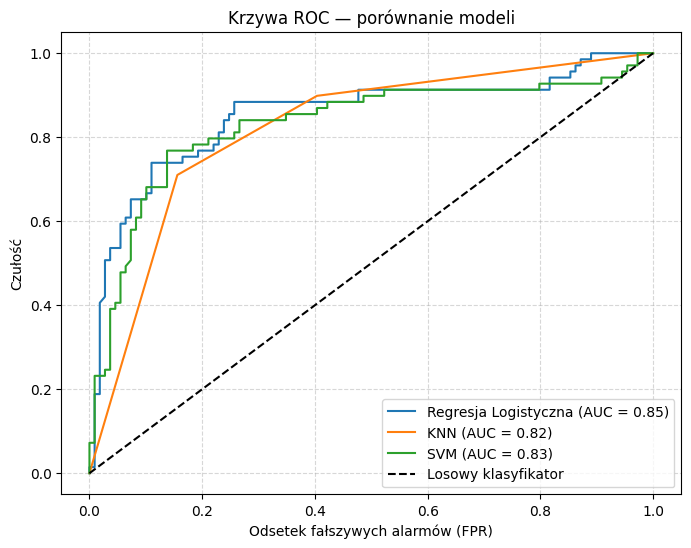

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

modele = {
    'Regresja Logistyczna': model_lr,
    'KNN': model_knn,
    'SVM': model_svm
}

for nazwa, model in modele.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.plot(fpr, tpr, label=f'{nazwa} (AUC = {auc(fpr, tpr):.2f})')

# Linia losowego klasyfikatora i podstawowa kosmetyka
plt.plot([0, 1], [0, 1], 'k--', label='Losowy klasyfikator') # 'k--' oznacza czarną przerywaną linię
plt.xlabel('Odsetek fałszywych alarmów (FPR)')
plt.ylabel('Czułość')
plt.title('Krzywa ROC — porównanie modeli')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Wnioski z krzywej ROC i AUC:

Wszystkie modele dobrze radzą sobie z klasyfikacją, przewyższając losowy klasyfikator. Regresja Logistyczna (AUC=0.85) i SVM (AUC=0.83) mają najwyższe wartości AUC. KNN ma nieco niższe AUC (0.82), co wskazuje na minimalnie gorszą zdolność do rozróżniania klas.

## 6.5. Granica decyzyjna modeli

Aby zwizualizować, jak każdy model "rysuje" granicę między klasą 0 (ofiara) a klasą 1 (ocalały), redukuję dane do dwóch najważniejszych cech: **Sex** (płeć) i **Pclass** (klasa biletu). Dla każdego punktu w przestrzeni tych dwóch cech model podejmuje decyzję — zakoloruję te obszary, aby zobaczyć kształt granicy decyzyjnej.

### 6.5.1. Wizualizacja granic decyzyjnych (bez jitteringu)

Na początek wizualizuję granice decyzyjne modeli, używając tylko dwóch najważniejszych cech: **Płci (Sex)** i **Klasy Pasażerskiej (Pclass)**. Dane dla tych cech są dyskretne i zostały przeskalowane do zakresu [0, 1]. Każdy wykres pokazuje, jak dany model (Regresja Logistyczna, KNN, SVM) dzieli przestrzeń na obszary 'nie przeżył' (czerwony) i 'przeżył' (niebieski). Punkty danych (pasażerowie) są naniesione na ten wykres, aby pokazać ich rzeczywiste położenie względem granic. Dzięki temu mogę zobaczyć, jak algorytmy klasyfikują poszczególne grupy pasażerów.

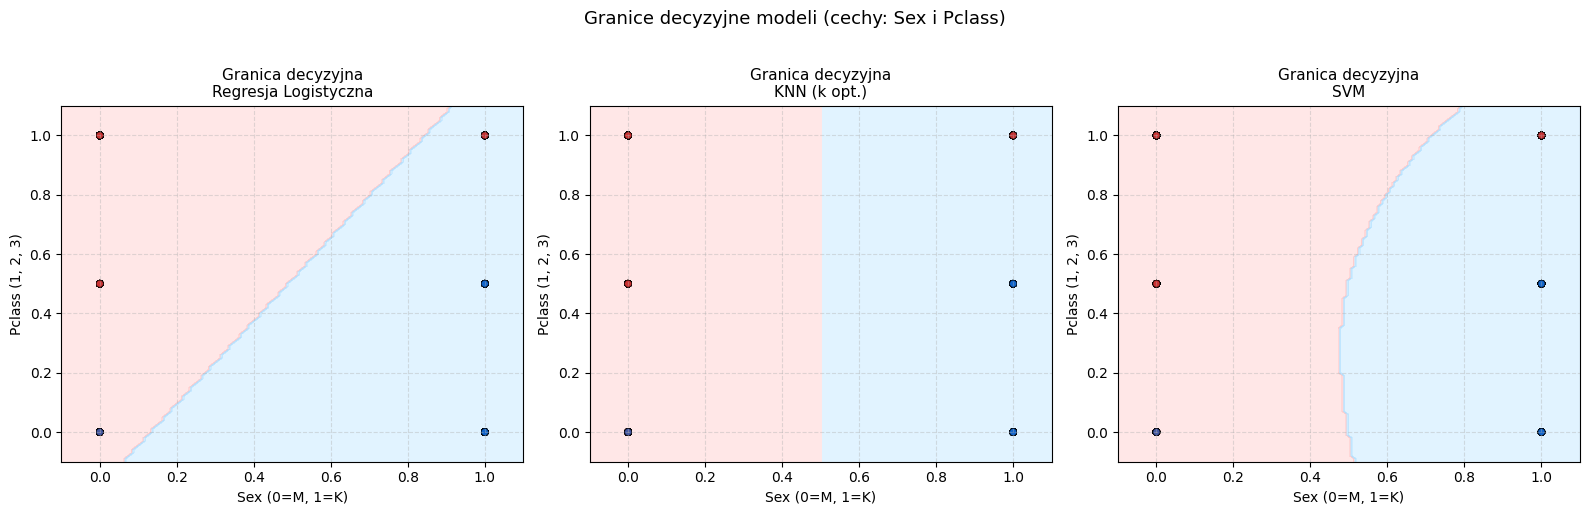

In [ ]:
from matplotlib.colors import ListedColormap

cechy_2d = ['Sex', 'Pclass']
X_2d = X_scaled[cechy_2d].values
y_2d = y.values

modele_db = {
    'Regresja Logistyczna': LogisticRegression(random_state=42),
    'KNN (k opt.)': KNeighborsClassifier(n_neighbors=najlepsze_k),
    'SVM': SVC(**najlepsze_parametry_svm, random_state=42, probability=True)
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cmap_light = ListedColormap(['#FFBBBB', '#AADDFF'])
cmap_bold  = ListedColormap(['#CC3333', '#1166CC'])

h = 0.01
x_min, x_max = X_2d[:, 0].min() - 0.1, X_2d[:, 0].max() + 0.1
y_min, y_max = X_2d[:, 1].min() - 0.1, X_2d[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

for ax, (nazwa, model) in zip(axes, modele_db.items()):
    model.fit(X_2d, y_2d)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_light)
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d,
                         cmap=cmap_bold, edgecolor='k', s=25, alpha=0.7, linewidth=0.4)
    ax.set_title(f'Granica decyzyjna\n{nazwa}', fontsize=11)
    ax.set_xlabel('Sex (0=M, 1=K)', fontsize=10)
    ax.set_ylabel('Pclass (1, 2, 3)', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Granice decyzyjne modeli (cechy: Sex i Pclass)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 6.5.2. Wizualizacja granic decyzyjnych z "jitteringiem" ( szumem)

Ponieważ cechy `Sex` (płeć) i `Pclass` (klasa) po skalowaniu przyjmują jedynie kilka konkretnych wartości (0.0 i 1.0 dla płci, 0.0, 0.5 i 1.0 dla klasy), wiele punktów danych nakłada się na siebie na wykresie. W rezultacie trudno ocenić rzeczywistą gęstość punktów w danym miejscu.

Aby temu zaradzić, zastosowałam technikę **"jitteringu"**. Polega ona na dodaniu niewielkiego, losowego szumu (delikatnego przesunięcia) do każdej współrzędnej (płci i klasy) punktów danych przed ich wykreśleniem. Szum ten jest na tyle mały, że nie zmienia interpretacji położenia punktu (np. "mężczyzna" nadal jest w okolicy 0.0 na osi X), ale jednocześnie wystarczający, aby rozproszyć nakładające się punkty i ujawnić ich prawdziwą liczbę w poszczególnych obszarach. Granice decyzyjne modeli pozostają niezmienione, ponieważ modele były trenowane na oryginalnych, niezmodyfikowanych danych.

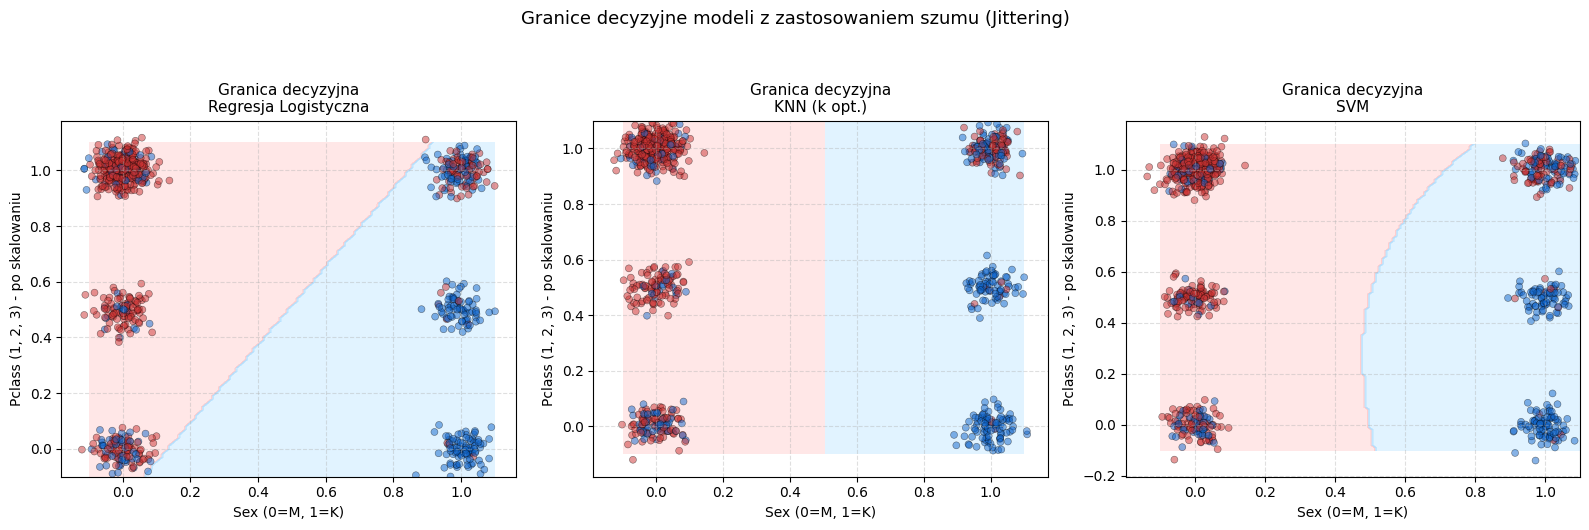

In [ ]:
# Definicja zmiennych i modeli
cechy_2d = ['Sex', 'Pclass']
X_2d = X_scaled[cechy_2d].values
y_2d = y.values

modele_db = {
    'Regresja Logistyczna': LogisticRegression(random_state=42),
    'KNN (k opt.)': KNeighborsClassifier(n_neighbors=najlepsze_k),
    'SVM': SVC(**najlepsze_parametry_svm, random_state=42, probability=True)
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cmap_light = ListedColormap(['#FFBBBB', '#AADDFF'])
cmap_bold  = ListedColormap(['#CC3333', '#1166CC'])

h = 0.01
x_min, x_max = X_2d[:, 0].min() - 0.1, X_2d[:, 0].max() + 0.1
y_min, y_max = X_2d[:, 1].min() - 0.1, X_2d[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

for ax, (nazwa, model) in zip(axes, modele_db.items()):
    # 1. Trenowanie modeli bez szumu
    model.fit(X_2d, y_2d)

    # 2. Rysowanie tła
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_light)

    # Dodawanie szumu (Jitter) do współrzędnych wykresu
    szum_x = np.random.normal(0, 0.04, size=X_2d[:, 0].shape)
    szum_y = np.random.normal(0, 0.04, size=X_2d[:, 1].shape)

    # 3. Rysowanie kropek (do oryginalnych osi dodajemy szum)
    # Zmniejszyłem lekko alpha (przezroczystość) na 0.5, żeby lepiej było widać nakładanie się kropek
    scatter = ax.scatter(X_2d[:, 0] + szum_x, X_2d[:, 1] + szum_y, c=y_2d,
                         cmap=cmap_bold, edgecolor='k', s=25, alpha=0.5, linewidth=0.4)

    # Kosmetyka osi
    ax.set_title(f'Granica decyzyjna\n{nazwa}', fontsize=11)
    ax.set_xlabel('Sex (0=M, 1=K)', fontsize=10)
    ax.set_ylabel('Pclass (1, 2, 3) - po skalowaniu', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Granice decyzyjne modeli z zastosowaniem szumu (Jittering)', fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

### Wnioski z wizualizacji granic decyzyjnych:

Wykresy granic decyzyjnych z dodaniem "szumu" dostarczają cennych informacji na temat sposobu, w jaki każdy z modeli klasyfikuje pasażerów w oparciu o ich Płeć (`Sex`) i Klasę Pasażerską (`Pclass`):

*   **Wpływ Płci (Sex)**: We wszystkich modelach granica decyzyjna silnie oddziela mężczyzn od kobiet. Jest to zgodne z wcześniejszymi analizami (macierz korelacji, ranking istotności cech), które wskazywały płeć jako najważniejszy predyktor przeżycia. Kobiety (szczególnie z wyższych klas) mają znacznie większą szansę na przeżycie.

*   **Wpływ Klasy Pasażerskiej (Pclass)**: Klasa biletu również odgrywa istotną rolę. Modele wyraźnie pokazują, że szanse na przeżycie malały wraz z obniżeniem klasy (czyli wzrastaniem wartości Pclass po skalowaniu). Granice decyzyjne układają się w taki sposób, aby preferować przeżycie pasażerów z klasy 1 i 2, a szczególnie kobiet z tych klas.

*   **Różnice między Modelami**:
    *   **Regresja Logistyczna** tworzy względnie prostą, liniową granicę, która stara się najlepiej oddzielić klasy.
    *   **KNN** tworzy bardziej nieregularne granice, które są silnie zależne od najbliższych sąsiadów. Widać "regiony" klasyfikacji, które są kształtowane przez skupiska punktów danych. Ze względu na małą wartość k=2, granice mogą być dość "poszarpane" i wrażliwe na pojedyncze punkty.
    *   **SVM z jądrem RBF** tworzy nieliniową granicę, która jest bardziej elastyczna niż regresja logistyczna, ale gładsza niż KNN. Widać, że SVM dobrze radzi sobie z tworzeniem stref, które obejmują skupiska pasażerów o podobnym statusie przeżycia, nawet jeśli wymagają one bardziej złożonego kształtu.

Ogólnie rzecz biorąc, wizualizacje potwierdzają dominujący wpływ płci i klasy na przeżycie, jednocześnie ujawniając subtelne różnice w tym, jak poszczególne algorytmy interpretują te zależności i budują swoje "reguły" klasyfikacji.

# 7. Podsumowanie i Wnioski Końcowe

## 7.1. Zestawienie metryk modeli — wykres porównawczy

Poniższy wykres zbiera wyniki wszystkich trzech modeli w jednym miejscu, pokazując Accuracy, F1-score dla klasy 0 (ofiary) oraz F1-score dla klasy 1 (ocalali). Pozwala to na szybkie, wizualne porównanie ich skuteczności.

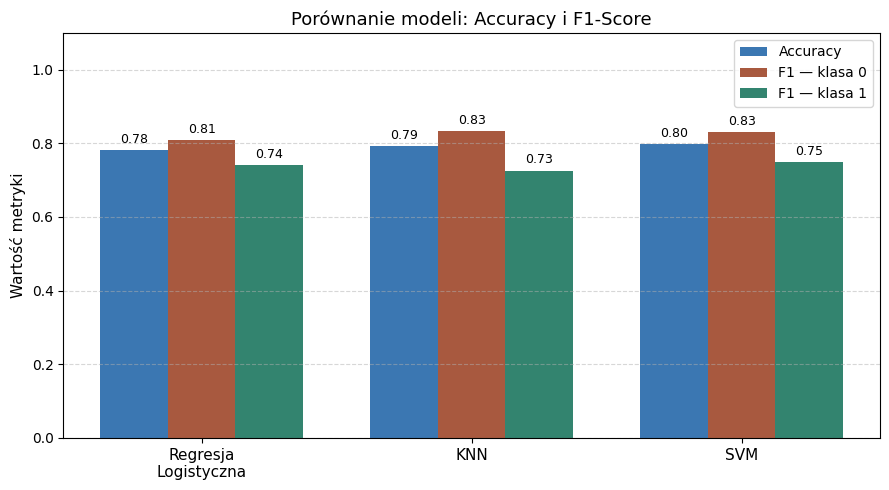

In [ ]:
from sklearn.metrics import f1_score

nazwy_modeli = ['Regresja\nLogistyczna', 'KNN', 'SVM']
predykcje = [y_pred_lr, y_pred_knn, y_pred_svm]

accuracy_list = [accuracy_score(y_test, p) for p in predykcje]
f1_klasa0     = [f1_score(y_test, p, pos_label=0) for p in predykcje]
f1_klasa1     = [f1_score(y_test, p, pos_label=1) for p in predykcje]

x = np.arange(len(nazwy_modeli))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width, accuracy_list, width, label='Accuracy',       color='#185FA5', alpha=0.85)
b2 = ax.bar(x,         f1_klasa0,     width, label='F1 — klasa 0',   color='#993C1D', alpha=0.85)
b3 = ax.bar(x + width, f1_klasa1,     width, label='F1 — klasa 1',   color='#0F6E56', alpha=0.85)

ax.set_ylim(0, 1.1)
ax.set_ylabel('Wartość metryki', fontsize=11)
ax.set_title('Porównanie modeli: Accuracy i F1-Score', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(nazwy_modeli, fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.2f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Wnioski z porównania modeli:
Wszystkie trzy modele radzą sobie dobrze z problemem klasyfikacji przeżycia na Titanicu. SVM okazał się nieznacznie najlepszy pod względem ogólnej dokładności i zbalansowania metryk dla obu klas.

## 7.2. Podsumowanie co robiłam i co wyszło w projekcie

### Cel Projektu

Celem projektu było zbudowanie i porównanie modeli klasyfikacji maszynowej w celu przewidywania, czy pasażer statku Titanic przeżył katastrofę, czy nie.

### Proces i Przygotowanie Danych

1.  **Wczytanie i Czyszczenie Danych**: Dane dotyczące pasażerów Titanica zostały wczytane i poddane procesowi czyszczenia. Usunięto kolumnę 'Cabin' ze względu na dużą liczbę brakujących wartości. Braki w kolumnie 'Embarked' zostały usunięte (2 wiersze), natomiast braki w kolumnie 'Age' uzupełniono medianą, dopasowaną dla każdej z podgrup (płeć i klasa biletu). Kolumny takie jak 'Name', 'Ticket', 'PassengerId' zostały usunięte jako nieistotne dla modelu.
2.  **Transformacja Danych**: Zmienne kategoryczne 'Sex' (płeć) i 'Embarked' (port zaokrętowania) zostały zmapowane na wartości liczbowe, aby mogły być przetwarzane przez algorytmy uczenia maszynowego.
3.  **Skalowanie Danych**: Wszystkie cechy numeryczne zostały przeskalowane do zakresu [0, 1] za pomocą `MinMaxScaler`. Było to kluczowe dla modeli wrażliwych na skalę cech, takich jak KNN i SVM, zapobiegając dominacji cech o większych wartościach liczbowych.
4.  **Podział na Zbiór Treningowy i Testowy**: Dane zostały podzielone na zbiór treningowy (80%) i testowy (20%) w celu oceny zdolności generalizacyjnych modeli.
5.  **Balansowanie klas (SMOTE)**: Zastosowano metodę SMOTE na zbiorze treningowym, aby zbalansować klasy (przeżyli/nie przeżyli), co zapobiega problemowi modelu faworyzującego klasę większościową.

### Analiza Danych i Redukcja Wymiarowości

1.  **Analiza Statystyczna**: Podstawowe statystyki ujawniły niezbalansowanie klasy docelowej ('Survived'), z większą liczbą ofiar niż ocalałych przed zastosowaniem SMOTE. Zauważono również duży wpływ uzupełnienia braków w kolumnie 'Age' medianą.
2.  **Wizualizacja Rozkładów**: Wykresy potwierdziły silną korelację płci z przeżyciem (kobiety miały znacznie większe szanse).
3.  **Macierz Korelacji**: Potwierdzono, że 'Sex' (0.54) i 'Pclass' (-0.34) są cechami najsilniej korelującymi z przeżyciem.
4.  **Redukcja Wymiarowości (PCA i t-SNE)**:
    *   **PCA**: Ta metoda pomogła nam zobaczyć dane w dwóch wymiarach. Pokazała pewne grupy, ale kolory (przeżyli/nie przeżyli) mocno się mieszały. To znaczy, że nie dało się łatwo oddzielić grup prostą linią.
    *   **t-SNE**: Użyliśmy też innej metody, t-SNE, która jest lepsza do szukania bardziej złożonych, nieliniowych wzorców. Ona pokazała wyraźniejsze grupy pasażerów o podobnych cechach. Mimo to, w tych grupach nadal mieszały się kolory, co pokazuje, że problem jest trudny i wymaga zaawansowanych modeli.

### Budowa i Ocena Modeli

W projekcie zaimplementowano i oceniono trzy modele klasyfikacji:

1.  **Regresja Logistyczna (Logistic Regression)**:
    *   **Dokładność (Accuracy)**: 0.78 na zbiorze testowym.
    *   **Istotność Cech**: 'Sex' i 'Pclass' okazały się najistotniejszymi cechami.
    *   **Raport Klasyfikacji**: Dla klasy 0 (Nie przeżyli) Precision: 0.86, Recall: 0.76, F1-Score: 0.81. Dla klasy 1 (Przeżyli) Precision: 0.68, Recall: 0.81, F1-Score: 0.74. Model dobrze radził sobie z identyfikacją obu klas, wykazując szczególnie wysoką czułość dla klasy pozytywnej.

2.  **K-Najbliższych Sąsiadów (KNN)**:
    *   **Dobór Parametru `k`**: Optymalne k (2) wybrano za pomocą metody łokcia, co pozwoliło osiągnąć najlepszą dokładność.
    *   **Dokładność (Accuracy)**: 0.79 na zbiorze testowym.
    *   **Raport Klasyfikacji**: Dla klasy 0 (Nie przeżyli) Precision: 0.82, Recall: 0.84, F1-Score: 0.83. Dla klasy 1 (Przeżyli) Precision: 0.74, Recall: 0.71, F1-Score: 0.73. KNN skutecznie identyfikował ofiary, ale miał nieco niższą czułość dla ocalałych w porównaniu do Regresji Logistycznej.

3.  **Maszyna Wektorów Nośnych (SVM)**:
    *   **Optymalizacja Hiperparametrów**: Zastosowano `GridSearchCV` do znalezienia optymalnych parametrów C i kernel (najlepsze to 'C': 60, 'kernel': 'rbf').
    *   **Dokładność (Accuracy)**: 0.80 na zbiorze testowym, najlepszy wynik spośród trzech modeli.
    *   **Raport Klasyfikacji**: Dla klasy 0 (Nie przeżyli) Precision: 0.85, Recall: 0.81, F1-Score: 0.83. Dla klasy 1 (Przeżyli) Precision: 0.72, Recall: 0.78, F1-Score: 0.75. SVM wykazał bardzo dobrą ogólną wydajność, z solidnymi wynikami dla obu klas, osiągając najwyższą dokładność i dobrze zbalansowany F1-score dla klasy ocalałych.

### Ogólne Wnioski

*   **Skuteczność Modeli**: Wszystkie trzy modele osiągnęły dobrą dokładność (około 78-80%) oraz wysokie wartości AUC (0.82-0.85), co świadczy o tym, że wybrane cechy i metody przygotowania danych są skuteczne w przewidywaniu przeżycia na Titanicu.
*   **Kluczowe Cechy**: 'Sex' (płeć) i 'Pclass' (klasa biletu) okazały się niezmiennie najsilniejszymi predyktorami przeżycia, co jest zgodne z historycznymi danymi.
*   **Skalowania Danych**: Skalowanie danych miało kluczowe znaczenie, zwłaszcza dla modeli odległościowych (KNN, SVM), umożliwiając im skuteczne działanie.
*   **Złożoność Problemu**: Mimo dobrych wyników, wizualizacje (PCA i t-SNE) pokazały, że rozróżnienie tych, co przeżyli, od tych, co zginęli, nie jest proste. Problem jest dość złożony.
*   **Niezbalansowane Dane**: Zwrócenie uwagi na precyzję, czułość i F1-score było ważne ze względu na niezbalansowany zbiór danych, co pozwoliło na pełną ocenę modeli, w tym ich zdolności do poprawnego identyfikowania klasy mniejszościowej (przeżyli).

